In [1]:
! pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 42.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [3]:
from google.colab import userdata
myapi_key = userdata.get('GROQ_API_KEY')

In [4]:
from langchain_groq import ChatGroq

In [5]:
# llm object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

In [5]:
llm_obj.invoke('what is AI write in 2 words')

AIMessage(content='Artificial Intelligence', additional_kwargs={'reasoning_content': 'We need to answer: "what is AI write in 2 words". The user asks: "what is AI write in 2 words". Likely they want a two-word phrase that defines AI. Could be "intelligent automation" or "machine intelligence" or "artificial intelligence". But they ask "what is AI write in 2 words". That seems ambiguous. Possibly they want a two-word answer: "Artificial Intelligence". But that\'s already two words. So answer: "Artificial Intelligence". Probably that is correct.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 79, 'total_tokens': 197, 'completion_time': 0.123315617, 'completion_tokens_details': {'reasoning_tokens': 107}, 'prompt_time': 0.004560944, 'prompt_tokens_details': None, 'queue_time': 0.052267156, 'total_time': 0.127876561}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': N

In [ ]:
# Langchain
#     -----
#
# User -> prompt -> LLM ->Answer
# ----------------------------------// Linear application
#
# UseCase
# ------------
# Simple chat
# --------------
# User -> prompt -> LLM ->Answer
#
# RAG
# ----
# tool Calling
# ---------------
# User -> LLM -> Tool ->Observation ->Result
# ----

# Langgraph
# ----=====
#
#  G = (V,E)
#  framework - build AI application(complex workflow - multi-step - loop)
#
#
#  LangGraph Core components
# -------------------------------
# 1. State - information carried through workflow - schema
#    ------- // user defined class
#    every node can read/update the state
#
# 2. node - function - performs task
#           ---------// user defined function - function call arguments and return value //
#
# 3. edge - determine the flow - relationship among the nodes
#    ---- //loops + condition
#
# 4. Build the graph
# 5. run the graph (application)

# State
# ---------
class state_className(dict):
  question: str
  answer: str
  tool_result: list

# Node
# ---------
def function1(state: state_className):
  state['question'] = ''
  ....
  return state

# Node
# ---------
def function2(state: state_className):
  state['question'] = ''
  ....
  return state

# from langgraph.graph import StateGraph
# Create Graph
# BuildGraph_obj = StateGraph()
# BuildGraph_obj.set_entry_point("Node-Name1")
# BuildGraph_obj.add_node("Node-Name1",function1)
# BuildGraph_obj.add_node("Node-Name2",function2)
# BuildGraph_obj.add_node("Node-Name3",function3)
# BuildGraph_obj.add_node("Node-Name4",function4)
# BuildGraph_obj.add_node("Node-Name4",END)

# BuildGraph_obj.add_edge("Node1-Name1","Node2-Name")

# BuildGraph_obj.compile() ->graph/app
#
# app.invoke() ->result


In [6]:
from langgraph.graph import StateGraph

In [7]:
# define state
# -----------------
class State(dict):
  text: str

# define node1-task1
def step1(state_dict):
  state_dict['text'] = state_dict['text'] + "--> Step1"
  return state_dict

# define node2-task2
def step2(state_dict):
  state_dict['text'] = state_dict['text'] + "--> Step2"
  return state_dict

# Build the Graph
# -------------------
builder_obj = StateGraph(State)
builder_obj.add_node("task1",step1)
builder_obj.add_node("task2",step2)

builder_obj.set_entry_point("task1")
builder_obj.add_edge("task1","task2")

graph = builder_obj.compile()

# Run
# ----
result = graph.invoke({'text':'my user input'})
print(result)

{'text': 'my user input--> Step1--> Step2'}


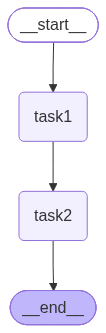

In [8]:
graph

In [9]:
# Start->[LLM]->End
# --------------------
# LangGraph + LLM

from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq

# State
class State(dict):
  question: str
  answer: str

# Create LLM object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

# define node
# --------------------
def call_llm(dict_state: State):
  response = llm_obj.invoke(dict_state['question'])
  return {'answer':response.content}

# Create a graph
# -----------------
builder = StateGraph(State)

# Add node
# ------------
builder.add_node("llm",call_llm)

# Add edge
# ------------
builder.add_edge(START,"llm")
builder.add_edge("llm",END)

# build the graph object
graph = builder.compile()

# Run
# ------
result = graph.invoke({'question':"What is LangGraph explain 5 words","answer":""})
print(result['answer'])

Graph-based framework powering language workflows.


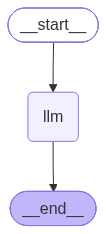

In [10]:
graph

In [11]:
# Run
# ------
result = graph.invoke({'question':"What is LangGraph explain 5 words"})
result

{'question': 'What is LangGraph explain 5 words',
 'answer': 'Graph‑based AI framework for dialogue.'}

In [14]:
from langgraph.graph import StateGraph, END
#from langchain_community.llms import Ollama

from langchain_groq import ChatGroq

# Define a simple state schema
class State(dict):
    messages: list

# Create Ollama LLM
#llm = Ollama(model="gemma2:2b")

# Create LLM object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)


# Define two nodes
def ask_topic(state: State):
    """Ask the user for a topic"""
    topic = input("Enter a topic to summarize: ")
    state["messages"] = [f"Summarize {topic} in one short paragraph."]
    return state

def summarize(state: State):
    """Generate summary using Ollama"""
    prompt = state["messages"][0]
    response = llm_obj.invoke(prompt)
    print("\n AI Summary:\n", response)
    return state

# Build LangGraph
graph = StateGraph(State)
graph.add_node("ask_topic", ask_topic)
graph.add_node("summarize", summarize)

# Connect nodes
graph.add_edge("ask_topic", "summarize")
graph.add_edge("summarize", END)

# Set entry point
graph.set_entry_point("ask_topic")

# Compile and run
app = graph.compile()
app.invoke({})


Enter a topic to summarize: AI news

 AI Summary:
 content='AI headlines this week spotlight GPT‑5’s rollout—now available in a “multimodal‑plus” version that can read PDFs, watch video clips, and generate code in a single prompt—while OpenAI tightens its policy on “dangerous” content. In healthcare, a new AI‑driven diagnostic platform has earned FDA clearance for early cancer detection, sparking debates over data privacy. Governments are moving forward with AI‑specific regulations: the EU’s AI Act is entering its third review phase, and China’s new “AI Ethics Law” mandates real‑time monitoring of autonomous systems. Meanwhile, climate‑modeling firms are using large‑language models to predict extreme weather events with unprecedented granularity, and researchers have released a benchmark for measuring AI alignment across diverse cultures. The tech community remains split over deep‑fake detection tech, as recent breakthroughs can now generate synthetic media that fools most current safe

{'messages': ['Summarize AI news in one short paragraph.']}

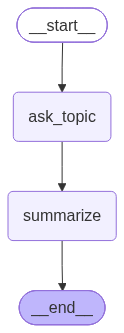

In [15]:
app

In [17]:
## Langgraph + LLM
# ---------------------
#  two nodes
#  ------------
#   node1 -> Question analyzer
#   node2 -> LLM answer the node1 question

# Start ->QuestionAnalyzer ->LLM ->END
# ------ =================  ====  -------
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq

# State
# ----------
class State(dict):
  question: str
  topic: str
  answer: str

# Create LLM object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

# node1- Questionanalyzer
# ------------------------
def question_analyzer(dict_state: State):
  question = dict_state['question']
  if 'python' in question.lower():
    topic_name = 'python'
  elif 'rag' in question.lower():
    topic_name = 'Generative AI'
  else:
    topic_name = 'AI news'
  return {'topic':topic_name}

# node-2 - llm-answer
# -----------------------
def generate_answer(dict_state: State):
  prompt = f"""
  Answer the following question:
  topic:{dict_state['topic']}
  Question:{dict_state['question']}"""
  response = llm_obj.invoke(prompt)
  return {'answer':response.content}

# Build LangGraph
graph = StateGraph(State)
graph.add_node("analyze",question_analyzer)
graph.add_node("generate",generate_answer)

# Connect nodes
graph.add_edge(START,"analyze")
graph.add_edge("analyze","generate")
graph.add_edge("generate",END)

app = graph.compile()
result = app.invoke({
    'question':'Explain in 5 words about RAG in Generative AI'
})
print('Topic:',result['topic'])
print('Answer:',result['answer'])

Topic: Generative AI
Answer: Retrieval-augmented generation improves contextual relevance.


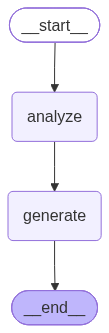

In [18]:
app

In [ ]:
# LLM + Tool
# --------
# User -> |  tool1  tool2  tool3 ... llm
#         |  ------------------------
#
#   Input
#    |
#   Router <==  decides which path to take
#   ------
#  Conditional Routing
#     (Router)
#        |
#   Is there errors?
#     | -----
#    Yes    No
#     |      |___node2 - END
#   node1
#
#
# State
# Node
# Edge
#   |-> Conditional Edge - decides which node to go to
#        add_conditional_edges("routerName",<router-function>,{node1,node2})

# Syntax:-
#------------
# add_conditional_edge("Source-Node",routing_function,{
#    "router-1","route1-function",
#    "router-2","route2-function"})


#-----------
# Think - like if-else/switch statement
#
#  choice =router(state)
# if choice == "success_node":
#     goto(success_node)
# elif choice == "erro_node":
#     goto(error_node)
#
# builder.add_conditional_edges(
#           "router",<router-function_name>, {'','','',''})


In [19]:
class State(dict):
  result: str

def router(state):
  if "error" in state['result']:
    return "error_node"
  return "success_node"

def error_node(state):
  state['result'] = 'Error Handled'

def success_node(state):
  state['result'] = 'SuccessPath'
  return state

builder = StateGraph(State)
builder.add_node("router",router)
builder.add_node("success_node",success_node)
builder.add_node("error_node",error_node)
builder.set_entry_point("router")

builder.add_conditional_edges(
    "router",router,{"success_node":"success_node","error_node":"error_node"}
)

graph = builder.compile()


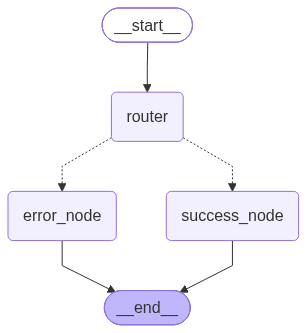

In [20]:
graph

In [21]:
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph import StateGraph,START,END

In [25]:
# 1. Create Tool
#--------------------
@tool
def add_numbers(a: int,b: int) ->int:
  '''add two number'''
  return a+b

# 2. Create LLM Object
#
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)
llm_with_tools = llm_obj.bind_tools([add_numbers])

# 3. Define state
#-----------------------
class State(dict):
  messages: list

# 4. LLM-node
#-------------------
def call_llm(dict_state: State):
  response = llm_with_tools.invoke(dict_state['messages'])
  return {"messages":dict_state['messages']+[response]}

# 5. Tool-node
#--------------------
def call_tool(dict_state: State):
  last_msg = dict_state['messages'][-1]
  tool_call = last_msg.tool_calls[0]
  args = tool_call['args']
  result = add_numbers.invoke(args) # execute the tool
  return {
      "messages":dict_state['messages']+[f'Tool result:{result}']
  }

# 6. Router
# --------------
def router(dict_state: State):
  last_msg = dict_state['messages'][-1]
  if last_msg.tool_calls:
    return "tool" # Invoke the tool function/node -> call_tool # refer buildgraph
  return "end"    # END

# 7. Build the Graph
builder = StateGraph(State)
builder.add_node('llm',call_llm)
builder.add_node('tool',call_tool)
builder.add_edge(START,'llm')

builder.add_conditional_edges('llm',router,
 {
     'tool':"tool",
     'end':END
})
builder.add_edge('tool','llm')

# 8. Compile
# -------------
graph = builder.compile()

# 9. Run
# ---------
result = graph.invoke({'messages':[('user',"what is 10+20?")]})






In [26]:
result

{'messages': [('user', 'what is 10+20?'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is 10+20?" We should compute 10+20=30. We can use the add_numbers function. We\'ll call it.', 'tool_calls': [{'id': 'fc_4024a170-bbb5-4eac-a8a7-5c4f77fbe110', 'function': {'arguments': '{"a":10,"b":20}', 'name': 'add_numbers'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 128, 'total_tokens': 190, 'completion_time': 0.064420934, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.00616637, 'prompt_tokens_details': None, 'queue_time': 0.314527507, 'total_time': 0.070587304}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a084f6-fd0c-7623-b4fe-0c22debf0fa3-0', tool_calls=[{'name': 'add_numbers', 'args': {'a': 10, 'b': 20}, 'id': 'fc_4024a170-bb

In [27]:
for var in result['messages']:
  print(var)

('user', 'what is 10+20?')
content='' additional_kwargs={'reasoning_content': 'The user asks: "what is 10+20?" We should compute 10+20=30. We can use the add_numbers function. We\'ll call it.', 'tool_calls': [{'id': 'fc_4024a170-bbb5-4eac-a8a7-5c4f77fbe110', 'function': {'arguments': '{"a":10,"b":20}', 'name': 'add_numbers'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 128, 'total_tokens': 190, 'completion_time': 0.064420934, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.00616637, 'prompt_tokens_details': None, 'queue_time': 0.314527507, 'total_time': 0.070587304}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a084f6-fd0c-7623-b4fe-0c22debf0fa3-0' tool_calls=[{'name': 'add_numbers', 'args': {'a': 10, 'b': 20}, 'id': 'fc_4024a170-bbb5-4eac-a8a7-5c4f77fbe110', 'ty

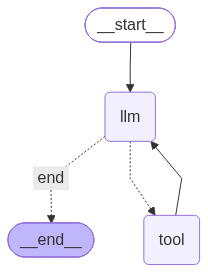

In [28]:
graph

In [29]:
# 9. Run
# ---------
result = graph.invoke({'messages':[('user',"what is langgraph explain in 3 words")]})

In [30]:
result

{'messages': [('user', 'what is langgraph explain in 3 words'),
  AIMessage(content='Graph‑based AI orchestration.', additional_kwargs={'reasoning_content': 'User: "what is langgraph explain in 3 words". They want a 3-word explanation of LangGraph. So answer succinctly: "Graph-based AI orchestration". Or "AI workflow engine". But 3 words: "Graph-based AI orchestration". That is 3 words? Graph-based (1), AI (2), orchestration (3). Yes. Or "AI workflow engine" (3 words). But maybe better: "Graph-based AI orchestration". Let\'s answer. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 121, 'prompt_tokens': 130, 'total_tokens': 251, 'completion_time': 0.130666437, 'completion_tokens_details': {'reasoning_tokens': 105}, 'prompt_time': 0.007656328, 'prompt_tokens_details': None, 'queue_time': 0.308998781, 'total_time': 0.138322765}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e594c51153', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logpro

In [ ]:
###

In [ ]:
# Conditional Routing - decision based
#
# Looping - retry mechanism
'''
START
|
Generate Report
|
Validate Report
|
is it correct
         |--> YES -----> END
         |
         |__  NO
              |
            Generate Report  }
            |                } - Loop - retry
            Validate Report  }

count - initialization
|->We invoke - initialization
|->every iteration - count value is incremented
|->Test
..
if state['count'] >= 5:
+--------------------+
| count  | next   |
| ------------------
|   0    | retry |
|   1    | retry |
|   2    | retry |
|   3    | retry |
|   4    | done  |
'''

In [31]:
class State(dict):
  count: int
  message: str

def check(state):
  if state['count'] >= 5:
    return "done"
  return "retry"

def increment(state):
  state['count'] += 1
  return state

def done(state): # this is final node
   state['message'] = "Finished"
   return state


builder = StateGraph(State)
builder.add_node("increment",increment)
builder.add_node("done",done)
builder.set_entry_point("increment")
builder.add_conditional_edges(
    "increment",
    check,
    {"retry":"increment","done":"done"}
)
graph = builder.compile()
print(graph.invoke({"count":0}))



{'count': 5, 'message': 'Finished'}


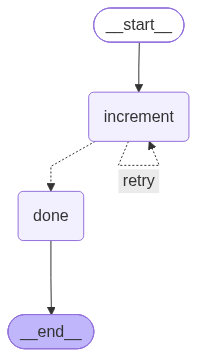

In [32]:
graph

In [36]:
## State
class State(dict):
  input: str
  answer: str
  attempts: int


# Generate node
def generate(state: State):
  attempts = state['attempts'] + 1
  print(f'Attempt:{attempts}')
  # simulate llm response
  if attempts < 3:
    answer = "This is bad answer"
  else:
    answer = "This is good answer"
  return {"answer":answer,"attempts":attempts}

# Validate
# -----------
def validate(state: State):
  print("validating:",state['answer'])
  return state

# Router
# --------
def retry_router(state: State):
  answer = state['answer']
  # Answer is good
  if "good" in answer:
    return "success"
  # maximum retry is matched
  if state['attempts'] >= 3:
    return "failed"
  # Try again
  return "retry"


# Build the graph
builder = StateGraph(State)
builder.add_node("generate",generate)
builder.add_node("validate",validate)

builder.add_edge(START,'generate')
builder.add_edge('generate','validate')

builder.add_conditional_edges(
    "validate",
    retry_router,
    {
        "success":END,
        "retry":"generate",
        "failed":END
    }
)

graph = builder.compile()

result = graph.invoke({
    "input":"Explain Langraph",
    "answer": "",
    "attempts":0
})
print(result)


Attempt:1
validating: This is bad answer
Attempt:2
validating: This is bad answer
Attempt:3
validating: This is good answer
{'input': 'Explain Langraph', 'answer': 'This is good answer', 'attempts': 3}


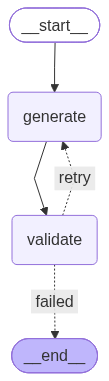

In [37]:
graph

In [ ]:
# Activity
## RAG - Agent tool

# 1. Load Excel/PDF/TextFile

# 2. Chunks

# 3. Embedding model

# 4. Vectorstores
# 5. Create retriever object

# 6. Create LLM
#
# 7. Create RAG Tool node -> @tool
#       7.1. Retrieve relevent documents -> retriever_obj.invoke(question)
#       7.2  combine retrieved content
#       7.3  Hybrid prompt
#       7.4  invoke llm object
#       7.5  return response content
#
# 8. Register tool
#    llm_obj.bind_tools() ->llm_with_tools

# 9. LangGraph state
# 10. Create Agent node
# 11. Tool routing
#
# 12. Build graph
#         |->add_node add_edge
#
# 13. compile and run
# 14. display - final answer

In [46]:
from langchain_community.document_loaders import UnstructuredExcelLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from typing import TypedDict,Annotated

from langchain_core.tools import tool
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage

In [53]:
# Step-1
loaderObj = UnstructuredExcelLoader('employee.xlsx')
docs = loaderObj.load()

# Step-2
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = text_splitter.split_documents(docs)

# Step-3
embedObj = HuggingFaceEmbeddings(model_name = "sentence-transformers/all-MiniLM-L6-v2")

# Step-4
vector_stores = FAISS.from_documents(chunks,embedObj)

# Step-5 - Create retriever
retriever_obj = vector_stores.as_retriever(search_kwargs={"k":2})

# Step-6 - llm object
llm_obj = ChatGroq(model="qwen/qwen3.8-27b",api_key=myapi_key)

# Step-7 Create RAG Tool
@tool
def employee_rag_tool(question: str) ->str:
  '''
  search employee.xlsx using semantic retrieval
  '''
  retrieved_docs = retriever_obj.invoke(question)
  # combine
  context = "\n\n".join(doc.page_content for doc in retrieved_docs)
  # Hybrid prompt
  my_prompt = """
    You are a strict employee QA assistant,
    Answer only using this information given context below.
    If answer is not present in the context,Answer from your general knowledge
    context:
    {context}
    Question:
    {question}
    Answer:"""
  response = llm_obj.invoke(my_prompt)
  return response.content

# Step - 8 Register tool
tools = [employee_rag_tool]
llm_with_tools = llm_obj.bind_tools(tools)


# Step- 9 LangGrpah state
# ------------------------
class AgentState(TypedDict):
  messages: Annotated[list,add_messages]

# Step-10 AgentNode
# ----------------
def agent_node(state: AgentState):
  messages = state['messages']
  system_messages = """
  You are an intelligent Agentic AI assistant.
  You have access to an employee excel RAG tool.
  You job is decide wheather a tool is required
  use employee_rag_tool when the user ask about
  - employee details
  - employee department
  - any information that may exists in employee.xlsx
  For general question that do not require employee.xlsx,
  answer directly using your knowlege."""
  v = [{'role':'system','content':system_messages}]+messages
  response = llm_with_tools.invoke(v)
  return {"messages":[response]}

# Step-11 Tool routing
#-----------------------
def should_continue(state: AgentState):
  messages = state['messages']
  lastmessage = messages[-1]
  if hasattr(lastmessage,"tool_calls"):
    return "tools"
  return END

# Step-12 Tool node
# ---------------
tool_node = ToolNode(tools)

# Step-13 Build Graph
builder = StateGraph(AgentState)

# add node
builder.add_node("agent",agent_node)
builder.add_node("tools",tool_node)
builder.add_edge(START,"agent") # START->Agent

# Agent ->Tool <or> END
builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tools":"tools",END: END}
)

# Tool ->Agent
builder.add_edge("tools","agent")


# Step - 14 Compile
graph = builder.compile()


# Step -15 Run
query = "Get sales employee details"

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [54]:
graph.invoke({"messages":[HumanMessage(content=query)]})

KeyboardInterrupt: 

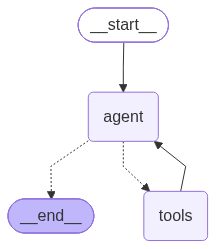

In [51]:
graph

In [ ]:
## ReAct = (Reason + Action)  - Live data
#-------------------------------
#  Design pattern - prompting framework
#
#  Thought ->Action ->Obervation... repeated until it has enough information to provide a final answer.
#
# Thought - Reasoning
# Action  - Execution
# Observation - Learning  - The backend framework runs the tool and feeds the raw results back to the llm
# the model will observes this new information,logs it into its context history  and starts the next loop
#                                             ==================================
#  by generating new thought..


def agent(state: State):
  prompt = f'''
  You are a ReAct agent.
  you can use :
  - calculator
  - websearch
  - sportsapi
  - tool1
  - tool2
  use this format
  Thought: what to do
  action: calculator or tool1 or tool2
  questions:{state['question']}'''

In [1]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.agents import create_agent

/tmp/ipykernel_102947/846748123.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [6]:
# llm object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

In [7]:
search = DuckDuckGoSearchRun()

In [10]:
# Create agent = LLM + tool

agent_obj = create_agent(
    model = llm_obj,
    tools = [search]
)

In [15]:
react_prompt = '''
You are an ReAct agent with access to weather information tool.
Goal: Answer this question: "What is the weather in bangalore and should i carry an umbrella if there is more
than 60% chance of rain?
Instructions: 1. Determine current weather information is required
2. if required use tool to retrive latest forecast for banglore
3. Examine the tool result
4. Identify the probability of rain
5. Apply this decision rule
6. if rain_probability 60% recommed carrying umbrella else say umbrella is not necessary
7. return weathersummary,rain probability,umbrella recommedndation'''

In [26]:
r = agent_obj.invoke({'messages':[{'role':'user','content':react_prompt}]})

In [27]:
r

{'messages': [HumanMessage(content='\nYou are an ReAct agent with access to weather information tool.\nGoal: Answer this question: "What is the weather in bangalore and should i carry an umbrella if there is more \nthan 60% chance of rain?\nInstructions: 1. Determine current weather information is required\n2. if required use tool to retrive latest forecast for banglore\n3. Examine the tool result\n4. Identify the probability of rain\n5. Apply this decision rule\n6. if rain_probability 60% recommed carrying umbrella else say umbrella is not necessary\n7. return weathersummary,rain probability,umbrella recommedndation', additional_kwargs={}, response_metadata={}, id='2fff3c57-675d-4319-9a47-7beadb5483c0'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to fetch current weather for Bangalore. Use weather tool? It says "You are an ReAct agent with access to weather information tool." But no tool listed. There\'s duckduckgo_search. Maybe use that to get weather. L

In [31]:
r.keys()

dict_keys(['messages'])

In [35]:
print(r['messages'][-1].content)

**Weather in Bangalore (September 8 2026)**  
- **Temperature:** ~26 °C (≈ 79 °F)  
- **Conditions:** Partly cloudy with occasional light showers; overall “Patchy rain nearby”   
- **Humidity:** ~57 %–59 %  
- **Wind:** 18–22 km/h (≈ 11–14 mph) from the west‑south‑west  
- **UV Index:** 12.6 (high)  

**Rain probability**  
- Forecast shows a **36 % chance of rainfall** for the day (source: recent local weather briefing).  

**Umbrella recommendation**  
- Since the rain probability (36 %) is **below the 60 % threshold**, an umbrella is **not necessary**.  
- If you plan to be outdoors for extended periods or in areas prone to sudden showers, carrying a lightweight rain jacket or a compact umbrella is still a good precaution.  

*Bottom line: Expect mild, partly cloudy weather with a modest chance of rain; you can go out without an umbrella.*


In [36]:
from langchain_groq import ChatGroq
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph,START,END

In [38]:
# LLM Object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

# Search Tool
search = DuckDuckGoSearchRun()

# Create ReAc Agent
agent_obj = create_agent(model=llm_obj,tools = [search])

# ReAct Instruction
react_prompt = """
You are an ReAct agent with access to weather information tool.
Goal:
Answer this question:
"What is the weather in bangalore and should i carry an umbrella if there is more than 60% chance of rain?
Instructions:
1. Determine current weather information is required
2. if required use tool to retrive latest forecast for banglore
3. Examine the tool result
4. Identify the probability of rain
5. Apply this decision rule
6. if rain_probability 60% recommed carrying umbrella else say umbrella is not necessary
7. return weathersummary,rain probability,umbrella recommedndation
"""

# Graph state
class State(dict):
  question: str
  answer: str

# Agent Node
# -----------
def agent_node(state):
  question = state['question']
  result = agent_obj.invoke({
      "messages":[
          ("system",react_prompt),
          ("user",question)
      ]
  })
  return {"answer":result["messages"][-1].content}

# Build Graph

graph = StateGraph(State)
graph.add_node("agent",agent_node)
graph.add_edge(START,"agent")

app = graph.compile()
result = app.invoke({
    "question":"What is the weather in Banglore?"
})
print(result["answer"])

**Weather in Bangalore (as of now)**  
- **Temperature:** ~86 °F (≈30 °C)  
- **Sky:** Mostly clear / sunny  
- **Wind:** Light breeze  
- **Humidity:** ~70 % (typical for the day)  

**Rain probability:** 20 %  

**Umbrella recommendation:**  
Since the chance of rain is **below 60 %**, you **do not need to carry an umbrella** at this time.


In [39]:
result

{'question': 'What is the weather in Banglore?',
 'answer': '**Weather in Bangalore (as of now)**  \n- **Temperature:** ~86\u202f°F (≈30\u202f°C)  \n- **Sky:** Mostly clear / sunny  \n- **Wind:** Light breeze  \n- **Humidity:** ~70\u202f% (typical for the day)  \n\n**Rain probability:** 20\u202f%  \n\n**Umbrella recommendation:**  \nSince the chance of rain is **below 60\u202f%**, you **do not need to carry an umbrella** at this time.'}

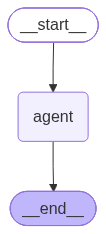

In [40]:
app

In [41]:
from langchain_groq import ChatGroq
#from langchain.agents import create_agent
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph,START,END

In [48]:
# LLM Object
llm_obj = ChatGroq(model="openai/gpt-oss-20b",api_key=myapi_key)

# Search Tool
search = DuckDuckGoSearchRun()

# Create ReAc Agent
#agent_obj = create_agent(model=llm_obj,tools = [search])
tools = [search]
agent_obj = llm_obj.bind_tools(tools)

# ReAct Instruction
react_prompt = """
You are an ReAct agent with access to weather information tool.
Goal:
Answer this question:
"What is the weather in bangalore and should i carry an umbrella if there is more than 60% chance of rain?
Instructions:
1. Determine current weather information is required
2. if required use tool to retrive latest forecast for banglore
3. Examine the tool result
4. Identify the probability of rain
5. Apply this decision rule
6. if rain_probability 60% recommed carrying umbrella else say umbrella is not necessary
7. return weathersummary,rain probability,umbrella recommedndation
"""

# Graph state
class State(dict):
  pass

# Agent Node
# -----------
def agent_node(state: State):
  question = state['question']
  result = agent_obj.invoke({
      "messages":[
          ("system",react_prompt),
          ("user",question)
      ]
  })
  return {"answer":result["messages"][-1].content}


# Router
def router(state):
  last_message = state['messages'][-1]
  if last_message.tool_calls:
    return "tools"
  return END

# Build Graph

graph = StateGraph(State)
graph.add_node("agent",agent_node)
graph.add_node("tools",ToolNode(tools))

# START ->Agent
graph.add_edge(START,"agent")

# Agent -> Tool <or> END
graph.add_conditional_edges("agent",router)

# Tool ->Agent
graph.add_edge("tools","agent")

app = graph.compile()

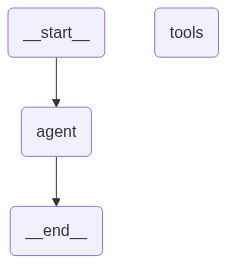

In [49]:
app

In [50]:
query = {"messages":[("user","What is the weather in Banglore?")]}
final_result = app.invoke(query)

KeyError: 'question'

In [ ]:
## Chain of Thought - CoT
# -------------------------------
# Reasoning Technique
#
# CoT -> Question ->Step1 ->Step2 ->Step3 ->FinalAnswer
#
#Question:
# A product cost is: 1000
# It has a 20% discount
# final price
#

#
# ReAct
# ------
# Reason(CoT) + Action(Tool)
#        ====

#


In [51]:
CoT = '''
Answer the following questions using a clear step-by-step Chain of Thought approch

Question:
Goal:
Answer this question:
"What is the weather in bangalore and should i carry an umbrella if there is more than 60% chance of rain?
Instructions:
1. Determine current weather information is required
2. if required use tool to retrive latest forecast for banglore
3. Examine the tool result
4. Identify the probability of rain
5. Apply this decision rule
6. if rain_probability 60% recommed carrying umbrella else say umbrella is not necessary
7. return weathersummary,rain probability,umbrella recommedndation'''

In [53]:
agent_obj.invoke(CoT)

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to answer question: "What is the weather in Bangalore and should I carry an umbrella if there is more than 60% chance of rain?" They want a chain-of-thought approach. They want to use a tool to retrieve latest forecast. They want to examine result, identify probability of rain, apply decision rule, recommend umbrella if >60% else not necessary. Return weather summary, rain probability, umbrella recommendation.\n\nWe need to use DuckDuckGo search to get weather forecast. Use the tool. Then parse. Let\'s search: "Bangalore weather forecast" or "Bangalore weather 2026" but likely they want current. We\'ll do a DuckDuckGo search.', 'tool_calls': [{'id': 'fc_03ff33d1-2c11-4743-bd6a-15edd4fbb78f', 'function': {'arguments': '{"query":"Bangalore weather forecast today"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 285, 'total_toke

In [54]:
r = agent_obj.invoke(CoT)
r.additional_kwargs['reasoning_content']

"We need to answer with step-by-step chain-of-thought. Need current weather in Bangalore and probability of rain. We need to use DuckDuckGo search to get latest forecast. Let's search."

In [55]:
agent_obj.invoke(CoT)

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer the question: "What is the weather in Bangalore and should I carry an umbrella if there is more than 60% chance of rain?" The instructions:\n\n1. Determine current weather information is required.\n2. If required use tool to retrieve latest forecast for Bangalore.\n3. Examine tool result.\n4. Identify probability of rain.\n5. Apply decision rule: if rain probability > 60% recommend carrying umbrella, else say umbrella not necessary.\n6. Return weather summary, rain probability, umbrella recommendation.\n\nWe need to use the DuckDuckGo Search tool. We\'ll search for "Bangalore weather forecast" or "Bangalore weather". Use the tool.\n\nLet\'s do that.', 'tool_calls': [{'id': 'fc_ec9c806f-0e23-4a6f-9814-a2213199a72b', 'function': {'arguments': '{"query":"Bangalore weather forecast"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 169, 'prompt_toke

In [66]:
problem="""A company has 120 employees. 40% are developers of the developers 25% work on AI projects. How many developers work on AI projects"""

normal_promt = """How many developers work on AI projects?"""
#
CoT = """How many developers work on AI projects? Solve this problem using Chain of Thougt Technique"""

In [57]:
CoT = '''
Answer the following questions using a clear step  by step approach
Question:
A company has 120 employees. 40% are developers of the developers 25% work on AI projects. How many developers work on AI projects
'''
result = llm_obj.invoke(CoT)
print(result.content)

**Step‑by‑step solution**

1. **Find the number of developers**  
   - Total employees = 120  
   - Percentage that are developers = 40 %  
   \[
   \text{Developers} = 120 \times 0.40 = 48
   \]

2. **Determine how many of those developers work on AI projects**  
   - Percentage of developers on AI projects = 25 %  
   \[
   \text{AI developers} = 48 \times 0.25 = 12
   \]

**Answer:** **12 developers** work on AI projects.


In [63]:
result.additional_kwargs

{'reasoning_content': 'We need to solve: 120 employees, 40% are developers -> 0.40 * 120 = 48 developers. Of those developers, 25% work on AI projects -> 0.25 * 48 = 12 developers. So answer: 12 developers. Provide step-by-step.'}

In [67]:
normal_promt = normal_promt + problem
normal_promt

'How many developers work on AI projects?A company has 120 employees. 40% are developers of the developers 25% work on AI projects. How many developers work on AI projects'

In [69]:
llm_obj.invoke(normal_promt).additional_kwargs

{'reasoning_content': 'We need to interpret the question: "How many developers work on AI projects? A company has 120 employees. 40% are developers of the developers 25% work on AI projects. How many developers work on AI projects"\n\nWe have 120 employees total. 40% are developers. So number of developers = 0.40 * 120 = 48. Of those developers, 25% work on AI projects. So number of developers on AI = 0.25 * 48 = 12. So answer: 12 developers.\n\nWe need to respond. Probably just answer: 12 developers. Might add explanation.'}

In [70]:
llm_obj.invoke(normal_promt).content

'First calculate how many employees are developers:\n\n- 40\u202f% of 120 employees are developers  \n  \\(120 \\times 0.40 = 48\\) developers.\n\nNext, find how many of those developers work on AI projects:\n\n- 25\u202f% of the developers work on AI  \n  \\(48 \\times 0.25 = 12\\) developers.\n\n**Answer:** 12 developers work on AI projects.'

In [71]:
'''
Chain of Thought
Tree of Thought
Graph of Thought
'''
GoT= '''
You are an AI reasoning assistant using Graph of Thougt approach
Problem:
I want to build an AI-powered customer support application

Explore the problem as graph of interconnected thoughts
Create nodes foes
1. user requirement
2. LLM selection
3. RAG
4. Tools

Instructions:
- Generate multiple approaches
- Connect related thoughts
- Allow one thought to influence with multiple thoughts
Think of reasoning as interconnected graph'''

In [72]:
llm_obj.invoke(GoT)

AIMessage(content='Below is a **“Graph of Thought”** that captures the key concepts you’ll need to juggle when building an AI‑powered customer‑support app.  \nI’ve turned the problem into a **directed graph** so you can see how one idea influences many others, and I’ve sketched **four alternative high‑level approaches** that map onto that graph.\n\n---\n\n## 1. Core Nodes (thoughts)\n\n| Node | What it represents | Typical sub‑thoughts |\n|------|--------------------|----------------------|\n| **UserRequirement** | The *what* the business wants (e.g., 24/7 support, multi‑language, SLA compliance). | • Volume & peak load<br>• Response time goals<br>• Domain specificity<br>• Privacy / regulatory constraints |\n| **LLMSelection** | Which language model(s) to use (size, architecture, provider, custom‑fine‑tuned). | • GPT‑4, Llama‑2, Claude, custom‑model<br>• Fine‑tuning strategy<br>• In‑house vs. hosted |\n| **RAG** (Retrieval‑Augmented Generation) | How the LLM will be fed external knowle

In [ ]:
# CoT,ToT,GoT = Reasoning ---> ReAct (Reason) + Action(Tool) + Observation
# ------------------------

In [ ]:
###   End of the DAY3 ######